In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.options.display.float_format = '{:,.2f}'.format
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_palette('husl')

con = duckdb.connect('../data/processed/ecommerce.duckdb')
con.execute("""
    CREATE VIEW IF NOT EXISTS ecommerce_clean AS
    SELECT * FROM read_parquet('../data/processed/ecommerce_clean.parquet')
""")

print("Ready!")

Ready!


In [2]:
cohort = con.execute("""
    WITH first_purchase AS (
        SELECT
            user_id,
            MIN(event_date)     AS cohort_date,
            DATE_TRUNC('week', MIN(event_date)) AS cohort_week
        FROM ecommerce_clean
        GROUP BY user_id
    ),
    user_activity AS (
        SELECT
            e.user_id,
            f.cohort_week,
            DATE_TRUNC('week', e.event_date)    AS activity_week,
            DATEDIFF('week',
                f.cohort_week,
                DATE_TRUNC('week', e.event_date)
            )                                   AS week_number
        FROM ecommerce_clean e
        JOIN first_purchase f ON e.user_id = f.user_id
    )
    SELECT
        cohort_week,
        week_number,
        COUNT(DISTINCT user_id)     AS active_users
    FROM user_activity
    GROUP BY cohort_week, week_number
    ORDER BY cohort_week, week_number
""").df()

cohort['cohort_week'] = pd.to_datetime(cohort['cohort_week'])

print("Cohort data built!")
print(f"   Cohort weeks : {cohort['cohort_week'].nunique()}")
print(f"   Week numbers : 0 - {cohort['week_number'].max()}")
display(cohort.head(10))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Cohort data built!
   Cohort weeks : 5
   Week numbers : 0 - 4


,cohort_week,week_number,active_users
0,2019-09-30,0,833311
1,2019-09-30,1,299059
2,2019-09-30,2,268872
3,2019-09-30,3,233173
4,2019-09-30,4,150112
5,2019-10-07,0,758911
6,2019-10-07,1,206684
7,2019-10-07,2,168607
8,2019-10-07,3,99708
9,2019-10-14,0,617134


In [3]:
# Pivot cohort table
cohort_pivot = cohort.pivot_table(
    index='cohort_week',
    columns='week_number',
    values='active_users'
)

# Cohort size = week 0 (semua user di cohort tersebut)
cohort_size = cohort_pivot[0]

# Retention rate = active_users / cohort_size * 100
retention = cohort_pivot.divide(cohort_size, axis=0) * 100
retention = retention.round(2)

# Format index jadi string yang rapi
retention.index = retention.index.strftime('%Y-%m-%d')
cohort_pivot.index = cohort_pivot.index.strftime('%Y-%m-%d')

print("Retention Rate Table (%):")
display(retention)

Retention Rate Table (%):


week_number,0,1,2,3,4
cohort_week,,,,,
2019-09-30,100.00,35.89,32.27,27.98,18.01
2019-10-07,100.00,27.23,22.22,13.14,NaN
2019-10-14,100.00,22.57,11.84,NaN,NaN
2019-10-21,100.00,12.90,NaN,NaN,NaN
2019-10-28,100.00,NaN,NaN,NaN,NaN


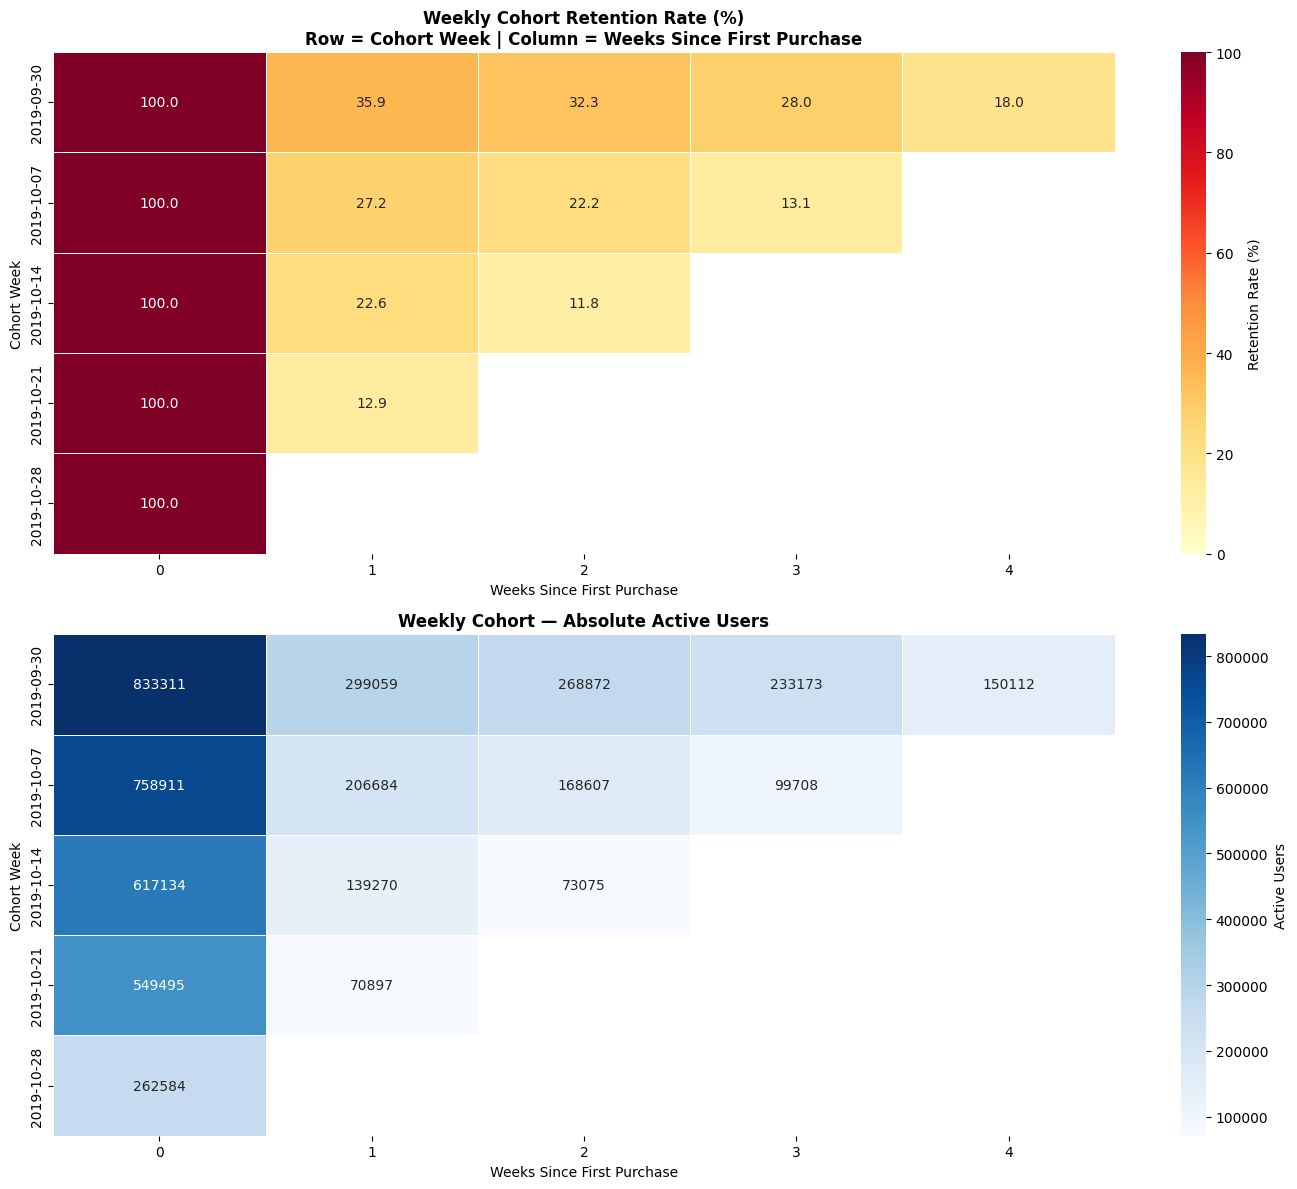

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Heatmap 1 — Retention Rate %
mask = retention.isnull()
sns.heatmap(
    retention,
    ax=axes[0],
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    mask=mask,
    linewidths=0.5,
    cbar_kws={'label': 'Retention Rate (%)'},
    vmin=0, vmax=100
)
axes[0].set_title('Weekly Cohort Retention Rate (%)\nRow = Cohort Week | Column = Weeks Since First Purchase',
                  fontweight='bold', fontsize=12)
axes[0].set_xlabel('Weeks Since First Purchase')
axes[0].set_ylabel('Cohort Week')

# Heatmap 2 — Absolute Users
sns.heatmap(
    cohort_pivot,
    ax=axes[1],
    annot=True,
    fmt='.0f',
    cmap='Blues',
    mask=mask,
    linewidths=0.5,
    cbar_kws={'label': 'Active Users'}
)
axes[1].set_title('Weekly Cohort — Absolute Active Users',
                  fontweight='bold', fontsize=12)
axes[1].set_xlabel('Weeks Since First Purchase')
axes[1].set_ylabel('Cohort Week')

plt.tight_layout()
plt.savefig('../reports/figures/16_cohort_retention.png',
            dpi=150, bbox_inches='tight')
plt.show()

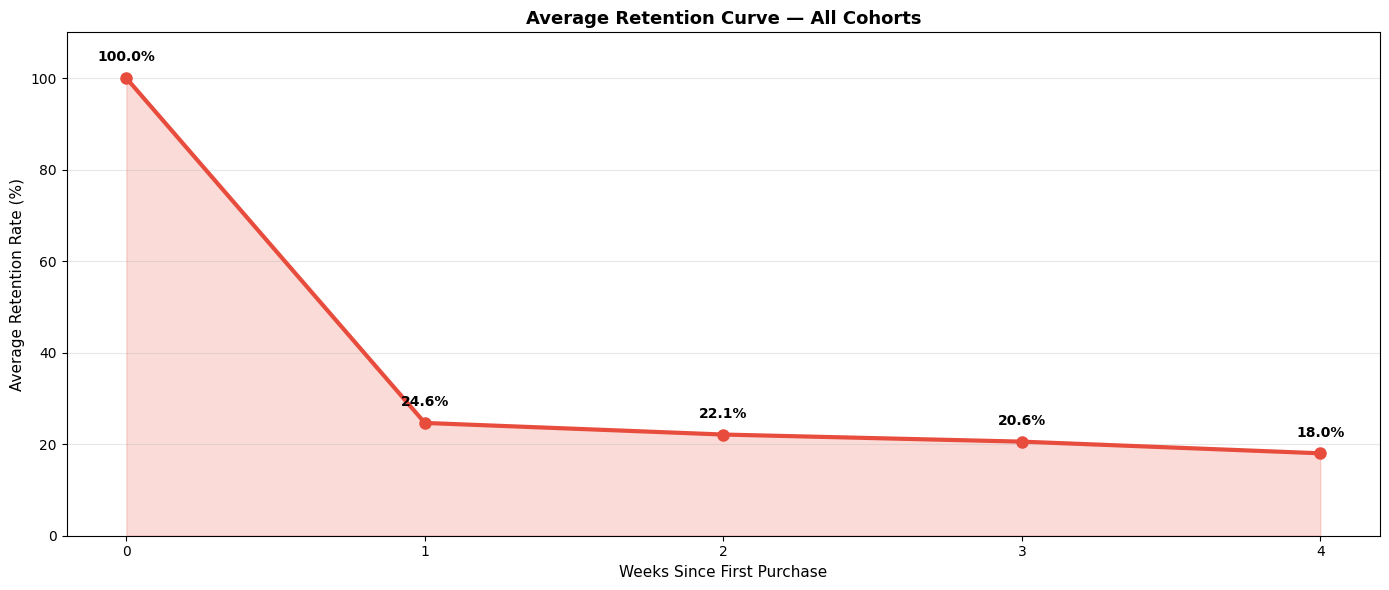


Retention Summary:
  Week 0   | ████████████████████ 100.0%
  Week 1   | ████                 24.6%
  Week 2   | ████                 22.1%
  Week 3   | ████                 20.6%
  Week 4   | ███                  18.0%


In [5]:
# Average retention per week across semua cohort
avg_retention = retention.mean(axis=0).reset_index()
avg_retention.columns = ['week_number', 'avg_retention_rate']

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(avg_retention['week_number'],
        avg_retention['avg_retention_rate'],
        color='#e74c3c', linewidth=3,
        marker='o', markersize=8)

ax.fill_between(avg_retention['week_number'],
                avg_retention['avg_retention_rate'],
                alpha=0.2, color='#e74c3c')

# Annotasi tiap titik
for _, row in avg_retention.iterrows():
    ax.annotate(f"{row['avg_retention_rate']:.1f}%",
                xy=(row['week_number'], row['avg_retention_rate']),
                xytext=(0, 12), textcoords='offset points',
                ha='center', fontsize=10, fontweight='bold')

ax.set_title('Average Retention Curve — All Cohorts',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Weeks Since First Purchase', fontsize=11)
ax.set_ylabel('Average Retention Rate (%)', fontsize=11)
ax.set_xticks(avg_retention['week_number'])
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 110)

plt.tight_layout()
plt.savefig('../reports/figures/17_retention_curve.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\nRetention Summary:")
for _, row in avg_retention.iterrows():
    bar = '█' * int(row['avg_retention_rate'] / 5)
    print(f"  Week {int(row['week_number']):<3} | {bar:<20} {row['avg_retention_rate']:.1f}%")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

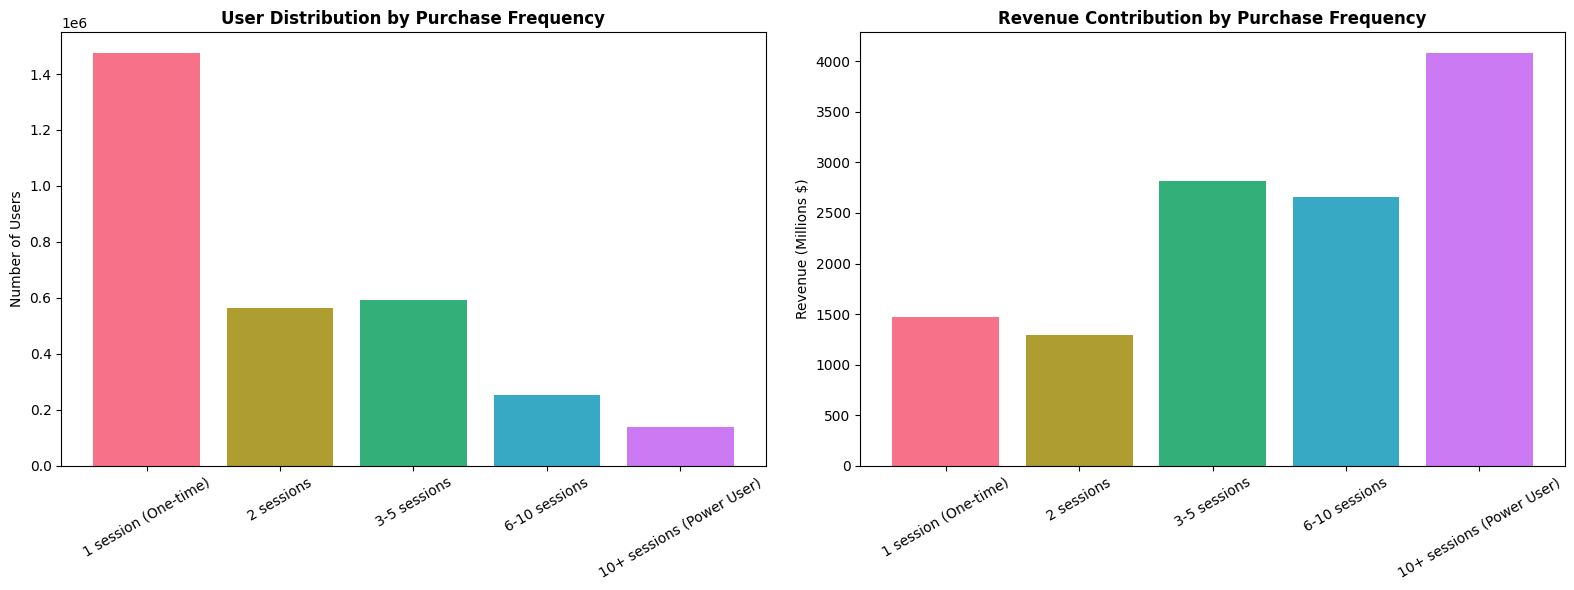


Repeat Purchase Summary:


,purchase_segment,user_count,avg_spending,avg_days_active,total_revenue_millions
0,1 session (One-time),1475204,997.82,0.00,"1,471.99"
1,2 sessions,565324,"2,286.10",5.20,"1,292.39"
2,3-5 sessions,590935,"4,768.48",10.30,"2,817.86"
3,6-10 sessions,251078,"10,588.88",15.80,"2,658.63"
4,10+ sessions (Power User),138894,"29,396.57",20.80,"4,083.01"


In [6]:
repeat = con.execute("""
    WITH user_purchase_count AS (
        SELECT
            user_id,
            COUNT(DISTINCT user_session)    AS total_sessions,
            COUNT(*)                        AS total_transactions,
            ROUND(SUM(price), 2)            AS total_spending,
            MIN(event_date)                 AS first_purchase,
            MAX(event_date)                 AS last_purchase,
            DATEDIFF('day',
                MIN(event_date),
                MAX(event_date))            AS days_active
        FROM ecommerce_clean
        GROUP BY user_id
    )
    SELECT
        CASE
            WHEN total_sessions = 1  THEN '1 session (One-time)'
            WHEN total_sessions = 2  THEN '2 sessions'
            WHEN total_sessions <= 5 THEN '3-5 sessions'
            WHEN total_sessions <= 10 THEN '6-10 sessions'
            ELSE '10+ sessions (Power User)'
        END                                 AS purchase_segment,
        COUNT(*)                            AS user_count,
        ROUND(AVG(total_spending), 2)       AS avg_spending,
        ROUND(AVG(days_active), 1)          AS avg_days_active,
        ROUND(SUM(total_spending)/1000000, 2) AS total_revenue_millions
    FROM user_purchase_count
    GROUP BY purchase_segment
    ORDER BY MIN(total_sessions)
""").df()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = sns.color_palette('husl', len(repeat))

# Chart 1 — User Count
axes[0].bar(repeat['purchase_segment'],
            repeat['user_count'],
            color=colors)
axes[0].set_title('User Distribution by Purchase Frequency',
                  fontweight='bold')
axes[0].set_ylabel('Number of Users')
axes[0].tick_params(axis='x', rotation=30)

# Chart 2 — Revenue Contribution
axes[1].bar(repeat['purchase_segment'],
            repeat['total_revenue_millions'],
            color=colors)
axes[1].set_title('Revenue Contribution by Purchase Frequency',
                  fontweight='bold')
axes[1].set_ylabel('Revenue (Millions $)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../reports/figures/18_repeat_purchase.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\nRepeat Purchase Summary:")
display(repeat)

In [7]:
one_time = repeat[repeat['purchase_segment'].str.contains('One-time')]
power    = repeat[repeat['purchase_segment'].str.contains('Power')]

one_time_pct = (one_time['user_count'].values[0] /
                repeat['user_count'].sum() * 100)

print("=" * 58)
print("       KEY INSIGHTS — COHORT & RETENTION ANALYSIS")
print("=" * 58)
print(f"""
RETENTION REALITY
   Check retention curve above:
   → Week 1 drop is the most critical moment
   → If user doesn't return in week 1, they rarely do

REPEAT PURCHASE BREAKDOWN
   One-time buyers : {one_time['user_count'].values[0]:,} users ({one_time_pct:.1f}%)
   → Biggest opportunity for growth
   → Win strategy: trigger 2nd purchase within 7 days
     via personalized recommendation + discount

POWER USERS (10+ sessions)
   {power['user_count'].values[0]:,} users
   Avg spending : ${power['avg_spending'].values[0]:,.0f}
   → These are your Champions from RFM analysis
   → Protect at all costs — loyalty program is critical

RECOMMENDATION
   Focus retention budget on:
   1. Week 0→1 transition (highest drop-off)
   2. Converting one-time buyers to 2nd purchase
   3. Maintaining power user engagement
""")
print("=" * 58)

       KEY INSIGHTS — COHORT & RETENTION ANALYSIS

RETENTION REALITY
   Check retention curve above:
   → Week 1 drop is the most critical moment
   → If user doesn't return in week 1, they rarely do

REPEAT PURCHASE BREAKDOWN
   One-time buyers : 1,475,204 users (48.8%)
   → Biggest opportunity for growth
   → Win strategy: trigger 2nd purchase within 7 days
     via personalized recommendation + discount

POWER USERS (10+ sessions)
   138,894 users
   Avg spending : $29,397
   → These are your Champions from RFM analysis
   → Protect at all costs — loyalty program is critical

RECOMMENDATION
   Focus retention budget on:
   1. Week 0→1 transition (highest drop-off)
   2. Converting one-time buyers to 2nd purchase
   3. Maintaining power user engagement



In [8]:
con.close()
print("Cohort Analysis selesai!")
print("\nCharts saved:")
print("   16_cohort_retention.png")
print("   17_retention_curve.png")
print("   18_repeat_purchase.png")

Cohort Analysis selesai!

Charts saved:
   16_cohort_retention.png
   17_retention_curve.png
   18_repeat_purchase.png
